---
## **Projet Deep Learning**
## **Classification de tissus cancereux colorectaux**

---

---

**Ce notebook est concu pour etre :**
- **reproductible** (chemins relatifs, seeds fixees)
- **idempotent** (relancable sans retelecherger si les fichiers sont deja presents)
- **tracable** (quality gates go/no-go explicites)

---

---

# PARTIE 8 : AGENT IA (classification + recommandation)

---

---

## Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|--------|
| 1 | - | Header (noms, promo) |
| 2 | - | Principes reproductibilite |
| 3 | - | Titre Partie 8 |
| 4 | - | Plan du notebook |
| 5 | - | Objectif |
| 6 | Config | Imports + configuration |
| 7 | Embeddings | Export embeddings CNN v1 pour recommandation |
| 8 | Agent V1 | Demo 5 images (CNN v1 seul) |
| 9 | Agent V2 | Demo 5 images (ensemble + Grad-CAM) |
| 10 | Evaluation | V1 vs V2 sur test set complet |
| 11 | - | Conclusion |
| 12 | - | Timer |

---

---

### Objectif

Construire deux agents de classification de tissus histologiques :

- **Agent V1 (baseline)** : CNN v1 seul (436K params, ~91.78% test acc)
- **Agent V2 (ensemble)** : CNN v1 + ResNet-18 FT (ensemble pondere) + Grad-CAM + Claude API

Les deux agents partagent le module de recommandation (5 images similaires par cosine similarity sur embeddings CNN v1 128D).

Le code metier est factorise dans `src/agent_pathmnist.py` (aucune dependance Streamlit).

---

In [1]:
%matplotlib inline
print("=== Imports ===")

# Imports
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from medmnist import PathMNIST, INFO
from sklearn.metrics import accuracy_score, f1_score, classification_report
from pathlib import Path

print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")

# Reproductibilite
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {DEVICE}")

# Constants
DATA_DIR = os.path.join('.', 'data')
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
N_CLASSES = 9

# Load dataset
test_dataset = PathMNIST(split='test', download=False, root=DATA_DIR)
info = test_dataset.info
CLASSES = list(info['label'].values())
print(f"Classes  : {CLASSES}")
print(f"Test set : {len(test_dataset)} images")

# Agent import
BASE = Path('.').resolve()
sys.path.insert(0, str(BASE / 'src'))
from agent_pathmnist import (
    load_models, predict_v1, predict_v2, grad_cam,
    get_recommendations, export_test_embeddings, run_agent,
    explain_with_claude, create_cnn, build_resnet18,
    cnn_transform, resnet_transform, GradCAM,
    CLASSES as AGENT_CLASSES, CLASS_COLOR, CLASS_EMOJI,
    EMBEDDINGS_DIR
)

notebook_start_time = time.time()
print("\nImports OK")

=== Imports ===
Python   : 3.12.10
PyTorch  : 2.10.0+cu128
NumPy    : 2.4.3
Device   : cuda
Classes  : ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']
Test set : 7180 images

Imports OK


In [2]:
print("=== Export embeddings CNN v1 pour recommandation ===")
# Export CNN v1 embeddings (128D) for the full test set
# These will be used for cosine similarity recommendations

emb_path = EMBEDDINGS_DIR / 'cnn_test_embeddings.npy'

if emb_path.exists():
    print(f"Embeddings deja exportes : {emb_path}")
    embeddings = np.load(emb_path)
    labels_emb = np.load(EMBEDDINGS_DIR / 'cnn_test_labels.npy')
    print(f"Shape : {embeddings.shape}")
    print(f"Labels : {labels_emb.shape}")
else:
    print("Export en cours...")
    start = time.time()
    embeddings, labels_emb, images_emb = export_test_embeddings()
    elapsed = time.time() - start
    print(f"Temps : {elapsed:.1f}s")

# Reload models with embeddings
from agent_pathmnist import _cache
_cache.clear()
m = load_models()
print(f"Modeles charges : CNN v1 + ResNet FT")
print(f"Embeddings test : {'embeddings_test' in m}")

=== Export embeddings CNN v1 pour recommandation ===
Embeddings deja exportes : C:\STOCKAGE_XIA\DU SDA\DEEP LEARNING\PROJET\data\embeddings\cnn_test_embeddings.npy
Shape : (7180, 128)
Labels : (7180,)
Modeles charges : CNN v1 + ResNet FT
Embeddings test : True


=== Agent V1 : demo 5 images aleatoires ===
Image  5238 | True:                               background | Pred:                               background | Conf: 90.6% | OK
Image   912 | True:                               background | Pred:                               background | Conf: 100.0% | OK
Image   204 | True:     colorectal adenocarcinoma epithelium | Pred:     colorectal adenocarcinoma epithelium | Conf: 100.0% | OK
Image  6074 | True:     colorectal adenocarcinoma epithelium | Pred:     colorectal adenocarcinoma epithelium | Conf: 98.6% | OK
Image  2253 | True:                               background | Pred:                               background | Conf: 100.0% | OK


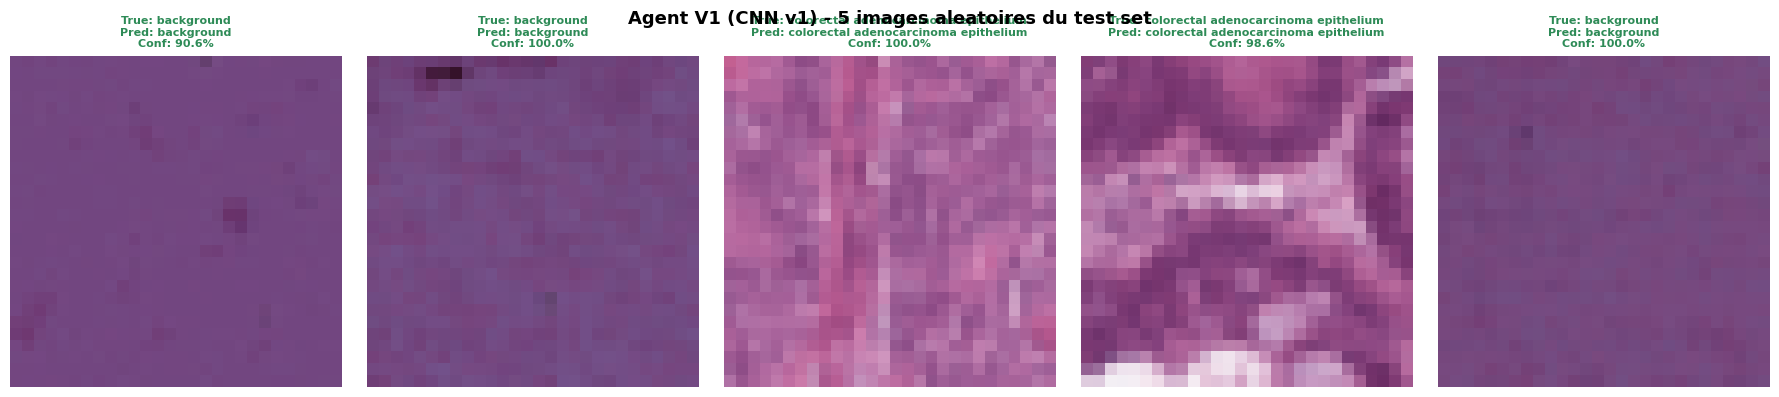

In [3]:
print("=== Agent V1 : demo 5 images aleatoires ===")
# Agent V1 demo: CNN v1 prediction on 5 random test images

import random
random.seed(SEED)
demo_indices = random.sample(range(len(test_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, idx in enumerate(demo_indices):
    img, lbl = test_dataset[idx]
    img_np = np.array(img)
    true_label = int(lbl.flatten()[0])

    result_v1 = run_agent(img_np, mode='V1')

    pred_class = result_v1['pred_class']
    confidence = result_v1['confidence']
    correct = (result_v1['pred_idx'] == true_label)

    axes[i].imshow(img_np)
    color = '#2E8B57' if correct else '#DC143C'
    axes[i].set_title(
        f"True: {CLASSES[true_label]}\n"
        f"Pred: {pred_class}\n"
        f"Conf: {confidence:.1%}",
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].axis('off')

    print(f"Image {idx:>5d} | True: {CLASSES[true_label]:>40s} | "
          f"Pred: {pred_class:>40s} | Conf: {confidence:.1%} | "
          f"{'OK' if correct else 'ERREUR'}")

fig.suptitle('Agent V1 (CNN v1) - 5 images aleatoires du test set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB8_agent_v1_demo.png'),
            dpi=120, bbox_inches='tight')
plt.show()

=== Agent V2 : demo 5 images + Grad-CAM ===
Image  5238 | True:                               background | V2 Pred:                               background | Conf: 95.3% | OK
Image   912 | True:                               background | V2 Pred:                               background | Conf: 100.0% | OK
Image   204 | True:     colorectal adenocarcinoma epithelium | V2 Pred:     colorectal adenocarcinoma epithelium | Conf: 100.0% | OK
Image  6074 | True:     colorectal adenocarcinoma epithelium | V2 Pred:     colorectal adenocarcinoma epithelium | Conf: 99.3% | OK
Image  2253 | True:                               background | V2 Pred:                               background | Conf: 100.0% | OK


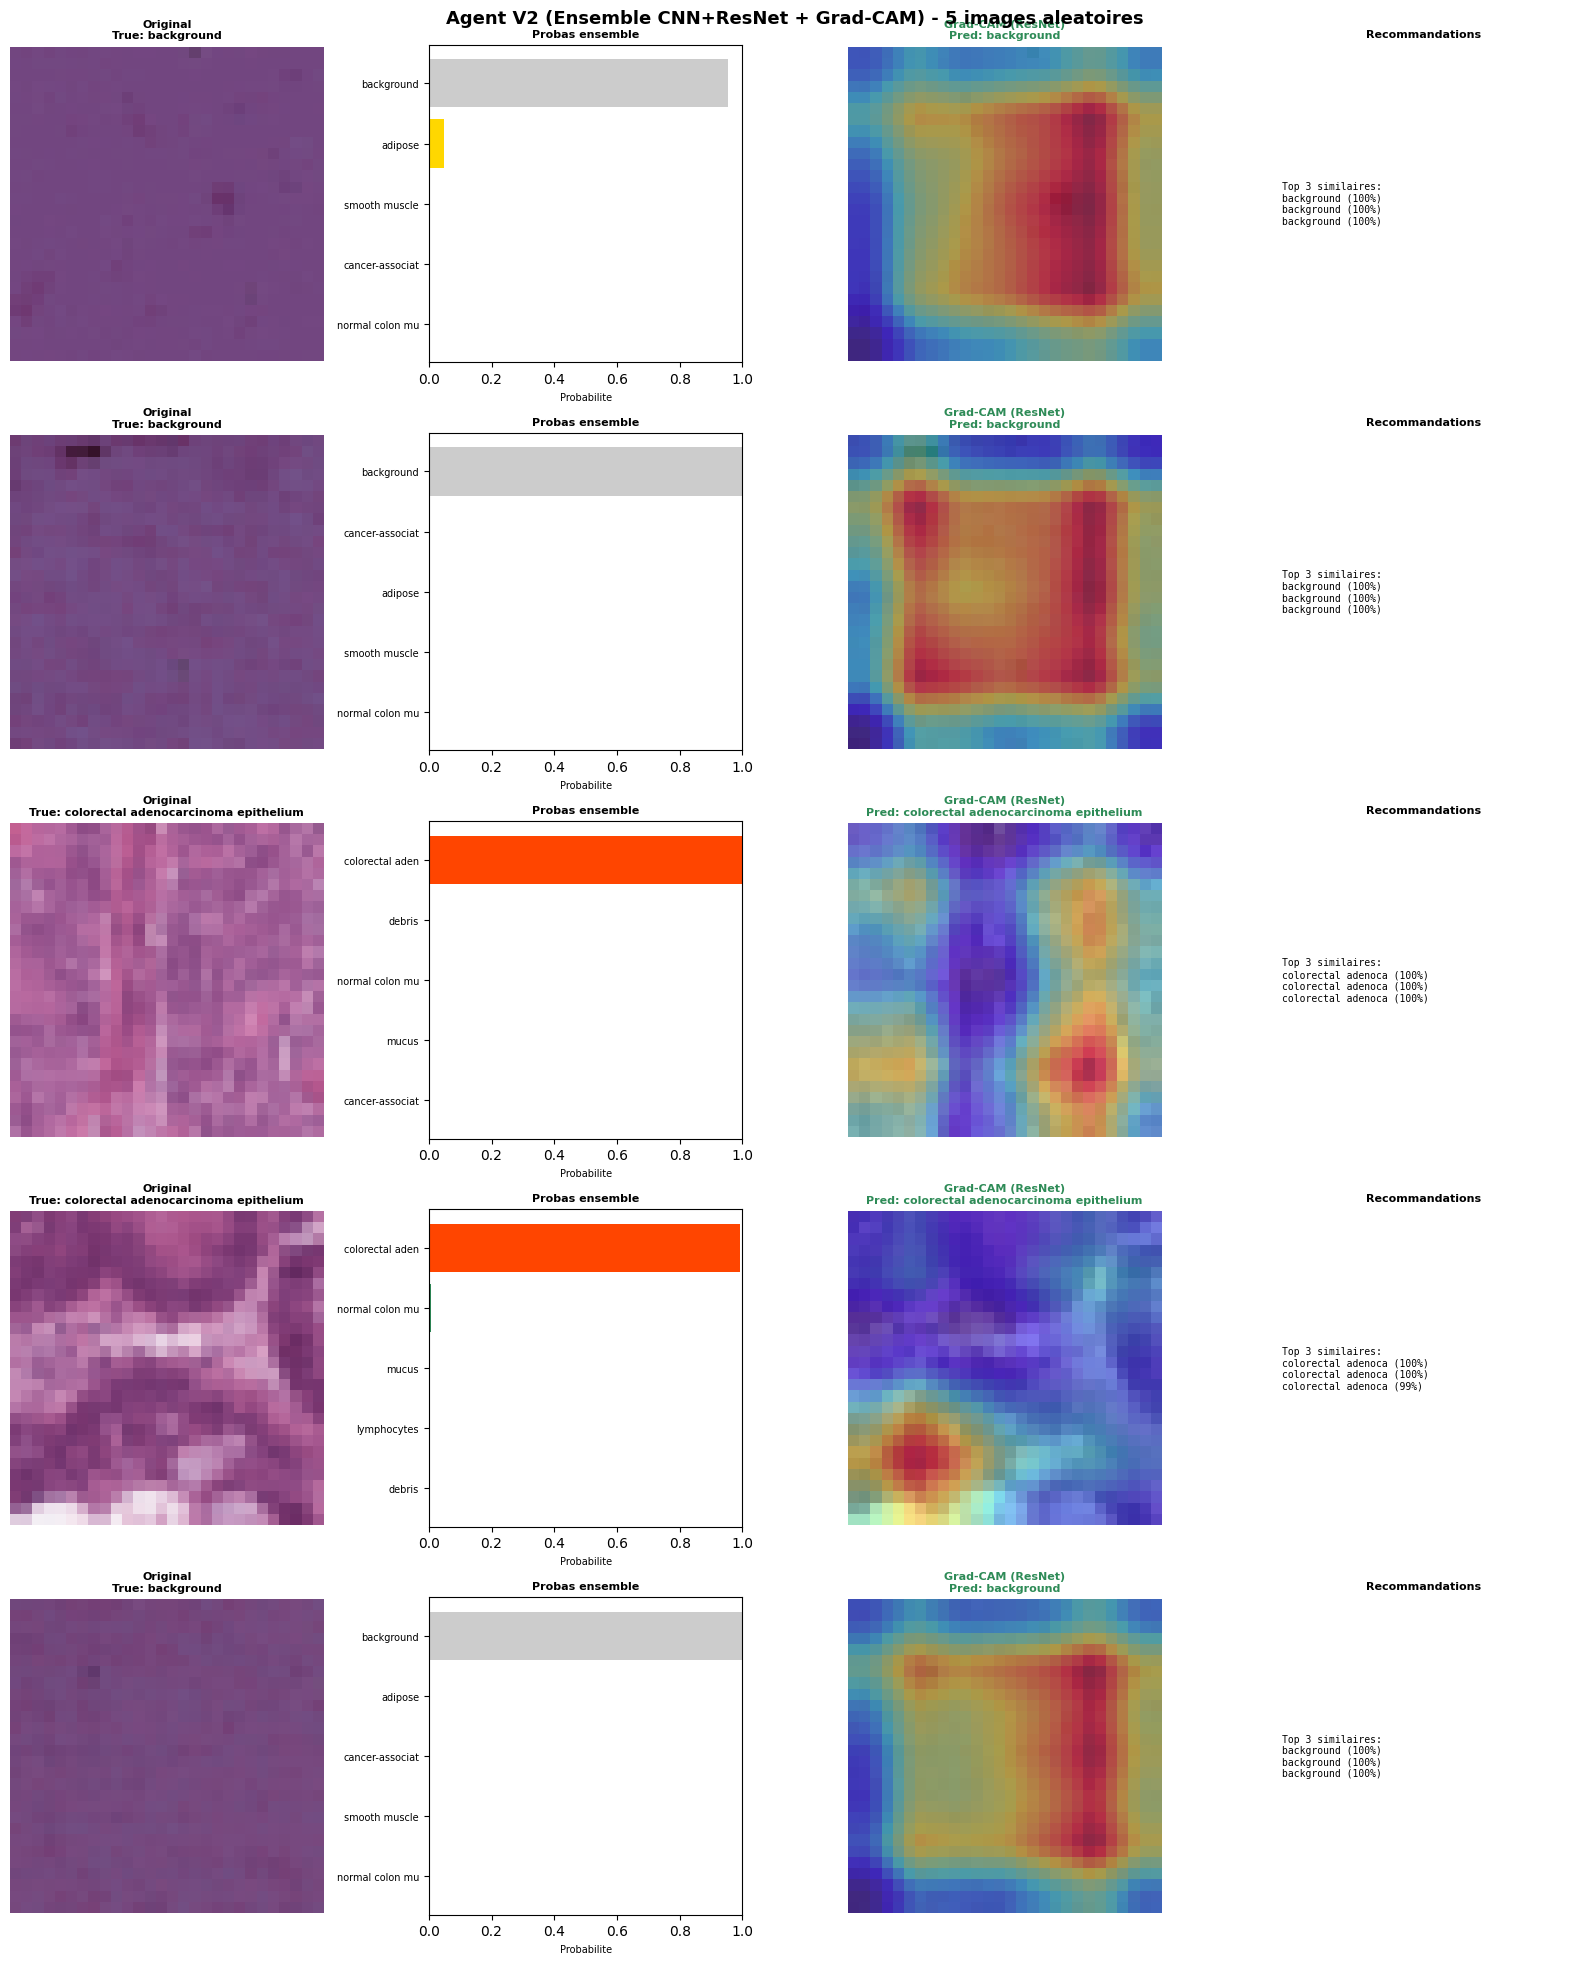

In [4]:
print("=== Agent V2 : demo 5 images + Grad-CAM ===")
# Agent V2 demo: ensemble + Grad-CAM on the same 5 images

fig, axes = plt.subplots(5, 4, figsize=(16, 20))

for i, idx in enumerate(demo_indices):
    img, lbl = test_dataset[idx]
    img_np = np.array(img)
    true_label = int(lbl.flatten()[0])

    result_v2 = run_agent(img_np, mode='V2')

    pred_class = result_v2['pred_class']
    confidence = result_v2['confidence']
    correct = (result_v2['pred_idx'] == true_label)

    # Column 0: Original image
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Original\nTrue: {CLASSES[true_label]}",
                          fontsize=8, fontweight='bold')
    axes[i, 0].axis('off')

    # Column 1: Confidence bar chart (top 5)
    top5 = result_v2['top_k'][:5]
    names = [t[0][:15] for t in top5]
    probs = [t[1] for t in top5]
    colors = [CLASS_COLOR.get(t[0], '#888') for t in top5]
    bars = axes[i, 1].barh(range(len(names)), probs, color=colors)
    axes[i, 1].set_yticks(range(len(names)))
    axes[i, 1].set_yticklabels(names, fontsize=7)
    axes[i, 1].set_xlabel('Probabilite', fontsize=7)
    axes[i, 1].set_xlim(0, 1)
    axes[i, 1].set_title('Probas ensemble', fontsize=8, fontweight='bold')
    axes[i, 1].invert_yaxis()

    # Column 2: Grad-CAM heatmap
    gcam_data = result_v2.get('grad_cam')
    if gcam_data is not None:
        axes[i, 2].imshow(gcam_data['overlay_28'])
        axes[i, 2].set_title(f"Grad-CAM (ResNet)\nPred: {pred_class}",
                              fontsize=8, fontweight='bold',
                              color='#2E8B57' if correct else '#DC143C')
    else:
        axes[i, 2].text(0.5, 0.5, 'N/A', ha='center', va='center')
        axes[i, 2].set_title('Grad-CAM', fontsize=8)
    axes[i, 2].axis('off')

    # Column 3: Recommendations
    reco = result_v2.get('recommendations', [])
    if reco:
        reco_text = '\n'.join(
            f"{r['class_name'][:18]} ({r['similarity']:.0f}%)"
            for r in reco[:3]
        )
        axes[i, 3].text(0.05, 0.5, f"Top 3 similaires:\n{reco_text}",
                        fontsize=7, va='center', transform=axes[i, 3].transAxes,
                        family='monospace')
    else:
        axes[i, 3].text(0.5, 0.5, 'Pas de reco', ha='center', va='center',
                        fontsize=8)
    axes[i, 3].set_title('Recommandations', fontsize=8, fontweight='bold')
    axes[i, 3].axis('off')

    status = 'OK' if correct else 'ERREUR'
    print(f"Image {idx:>5d} | True: {CLASSES[true_label]:>40s} | "
          f"V2 Pred: {pred_class:>40s} | Conf: {confidence:.1%} | {status}")

fig.suptitle('Agent V2 (Ensemble CNN+ResNet + Grad-CAM) - 5 images aleatoires',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs(os.path.join(DATA_DIR, 'graphs'), exist_ok=True)
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB8_agent_v2_demo.png'),
            dpi=120, bbox_inches='tight')
plt.show()

=== Evaluation V1 vs V2 sur test set complet ===
  1000/7180 images traitees...
  2000/7180 images traitees...
  3000/7180 images traitees...
  4000/7180 images traitees...
  5000/7180 images traitees...
  6000/7180 images traitees...
  7000/7180 images traitees...
Temps d'evaluation : 35.6s (0.6 min)

Metrique              Agent V1 (CNN)  Agent V2 (Ensemble)
----------------------------------------------------------
Accuracy                     91.77%              92.76%
F1 macro                     0.8900              0.9018

--- Classification Report V1 (CNN v1) ---
                                      precision    recall  f1-score   support

                             adipose     0.9517    0.9581    0.9549      1338
                          background     0.9894    0.9917    0.9906       847
                              debris     0.7865    0.8909    0.8354       339
                         lymphocytes     0.9489    0.9968    0.9723       634
                               mu

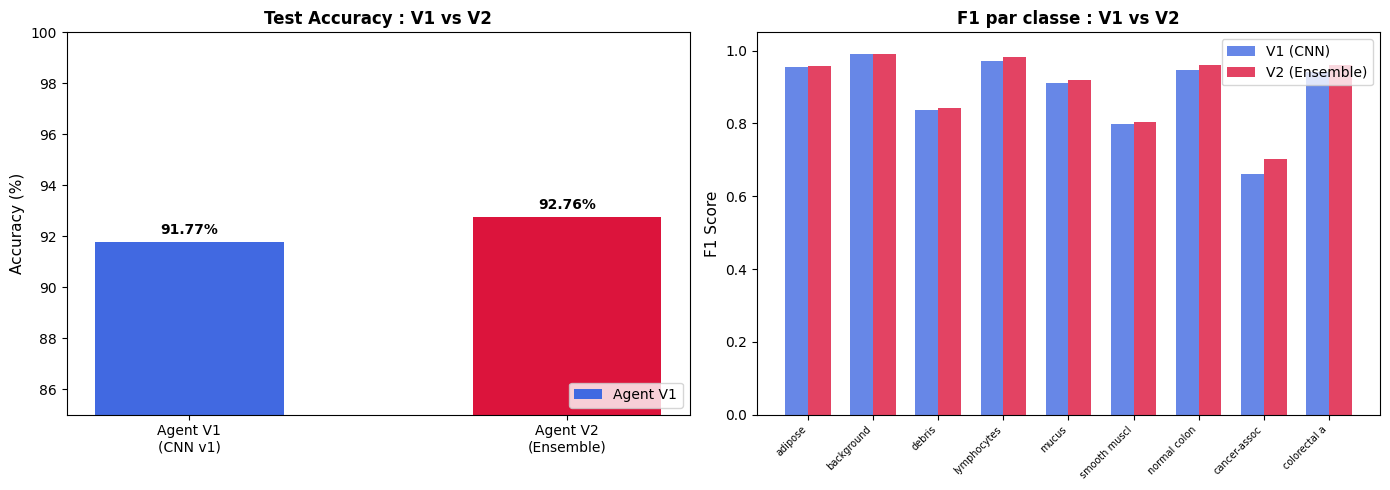

In [5]:
print("=== Evaluation V1 vs V2 sur test set complet ===")
# Evaluate both agents on the full test set

all_true = []
all_pred_v1 = []
all_pred_v2 = []

start_eval = time.time()
n_test = len(test_dataset)

for idx in range(n_test):
    img, lbl = test_dataset[idx]
    img_np = np.array(img)
    true_label = int(lbl.flatten()[0])

    r1 = predict_v1(img_np)
    r2 = predict_v2(img_np)

    all_true.append(true_label)
    all_pred_v1.append(r1['pred_idx'])
    all_pred_v2.append(r2['pred_idx'])

    if (idx + 1) % 1000 == 0:
        print(f"  {idx + 1}/{n_test} images traitees...")

eval_time = time.time() - start_eval
print(f"Temps d'evaluation : {eval_time:.1f}s ({eval_time/60:.1f} min)")

all_true = np.array(all_true)
all_pred_v1 = np.array(all_pred_v1)
all_pred_v2 = np.array(all_pred_v2)

# Metrics
acc_v1 = accuracy_score(all_true, all_pred_v1)
acc_v2 = accuracy_score(all_true, all_pred_v2)
f1_v1 = f1_score(all_true, all_pred_v1, average='macro')
f1_v2 = f1_score(all_true, all_pred_v2, average='macro')

print(f"\n{'Metrique':<20s} {'Agent V1 (CNN)':>15s} {'Agent V2 (Ensemble)':>20s}")
print('-' * 58)
print(f"{'Accuracy':<20s} {acc_v1:>14.2%} {acc_v2:>19.2%}")
print(f"{'F1 macro':<20s} {f1_v1:>14.4f} {f1_v2:>19.4f}")

# Per-class comparison
print("\n--- Classification Report V1 (CNN v1) ---")
print(classification_report(all_true, all_pred_v1, target_names=CLASSES, digits=4))

print("\n--- Classification Report V2 (Ensemble) ---")
print(classification_report(all_true, all_pred_v2, target_names=CLASSES, digits=4))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models_names = ['Agent V1\n(CNN v1)', 'Agent V2\n(Ensemble)']
accs = [acc_v1 * 100, acc_v2 * 100]
colors_bar = ['#4169E1', '#DC143C']
bars = axes[0].bar(models_names, accs, color=colors_bar, width=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Test Accuracy : V1 vs V2', fontsize=12, fontweight='bold')
axes[0].set_ylim(85, 100)
axes[0].legend(['Agent V1', 'Agent V2'], loc='lower right')

# Per-class F1 comparison
from sklearn.metrics import f1_score as f1_func
f1_v1_per = f1_func(all_true, all_pred_v1, average=None)
f1_v2_per = f1_func(all_true, all_pred_v2, average=None)

x = np.arange(N_CLASSES)
width = 0.35
axes[1].bar(x - width/2, f1_v1_per, width, label='V1 (CNN)', color='#4169E1', alpha=0.8)
axes[1].bar(x + width/2, f1_v2_per, width, label='V2 (Ensemble)', color='#DC143C', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([c[:12] for c in CLASSES], rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_title('F1 par classe : V1 vs V2', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB8_v1_vs_v2.png'),
            dpi=120, bbox_inches='tight')
plt.show()

---

## Conclusion

---

### Deux agents, deux niveaux

| | Agent V1 | Agent V2 |
|--|---------|----------|
| Modeles | CNN v1 (436K params) | CNN v1 + ResNet-18 FT (ensemble pondere) |
| Vitesse | Rapide (1 forward pass) | Plus lent (2 forward + Grad-CAM) |
| Interpretabilite | Aucune | Grad-CAM (zones d'attention) |
| Recommandation | Cosine similarity 128D | Cosine similarity 128D |
| Claude API | Non | Explication histologique |

### Points cles

- **L'ensemble ameliore-t-il l'accuracy ?** A verifier empiriquement ci-dessus. Les deux modeles ont des accuracy test tres proches (~91.7%), donc l'ensemble ne garantit pas un gain significatif. L'interet de V2 reside davantage dans l'interpretabilite (Grad-CAM) et la robustesse (deux architectures differentes).

- **Grad-CAM** permet de visualiser *ou* le modele regarde pour classifier. C'est crucial en histologie : si le modele se focalise sur les bonnes structures (glandes, noyaux, fibres), on gagne en confiance clinique.

- **Recommandation par embeddings** : les 128 features extraites avant la derniere couche du CNN capturent une representation compacte du tissu. La cosine similarity identifie des images visuellement et semantiquement proches.

### Limites

- L'ensemble a poids egaux (50/50) est naif. Un calibrage sur le val set (Platt scaling, temperature) pourrait optimiser les poids.
- Les images 28x28 limitent la resolution des heatmaps Grad-CAM.
- La recommandation est purement visuelle (embeddings CNN) et ne prend pas en compte le contexte clinique.

---

In [6]:
# Timer
total_time = time.time() - notebook_start_time
print(f"Temps total notebook : {total_time:.1f}s ({total_time/60:.1f} min)")

Temps total notebook : 37.7s (0.6 min)
